In [1]:
import sys
import deepwalk
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
def check_method(method):
    val = None
    if method == "kmedoids" or method =="Kmedoids":
        val = "kmedoids"
    elif method =="kmeans" or method == "Kmeans":
        val = "kmeans"
    elif method =="ward" or method =="Ward":
        val = "ward"
    else:
        sys.exit(f"methodの値が無効です method : {method}")
    return val

In [3]:
def check_data(data):
    data_list = ["football", "polbooks", "karateclub", "lesmis"]
    if data in data_list:
        pass
    else:
    
        sys.exit(f"変数dataの値が無効です data : {data}")

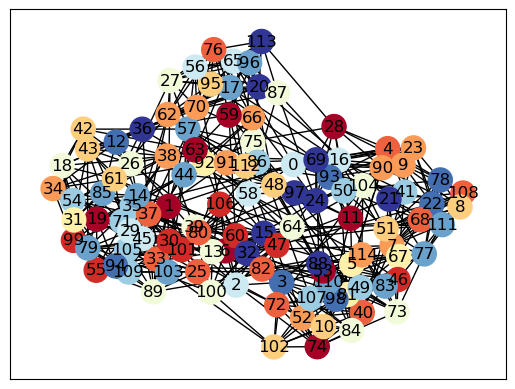

In [66]:
#実行回数(埋め込み-クラスタリング-ARI)
TIME = 100

"""
data : 使用するデータ
football   : "football"
polbooks   : "polbooks"
karateclub : "karateclub"
"""
data = "football"
check_data(data)

# インプットするグラフ生成とラベルの取得(ラベルなしデータはNone)
INPUT, TRUE_LABEL = deepwalk.generate_Graph(data)

#インプットするグラフが無向グラフかどうか(True:無向グラフ,　False:有向グラフ)
UNDIRECTED = True




# １ノードあたりの実行数
NUMBER_WALKS =10

# 1ウォークあたりの長さ
WALK_LENGTH = 20

# skipgramので使われるウィンドウサイズ
WINDOW_SIZE = 4




# ランダムシード値
SEED = 0

# 埋め込み後の各ノードの次元数
REPRESENTATION_SIZE = 2

# 並列プロセス数
WORKERS = 1

#クラスタ数
N_CLUSTER = 12

#クラスタリング手法
"""
kmedoids : "kmedoids"
kmeans   : "kmeans"
ward     : "ward"
"""
METHOD = check_method("ward")

#結果を表示するかどうか
SHOW = False

In [11]:
type(INPUT)

networkx.classes.graph.Graph

In [57]:
"""
    グラフ生成
    G = from_networkx(INPUT:networkxグラフインスタンス, 無効グラフかどうか:boolean)
    """
G = deepwalk.from_networkx(INPUT, True)
# ノード数出力
print("Number of nodes: {}".format(len(G.nodes())))

# ウォーク数算出(ノード数*1ノードあたりのウォーク数)と出力
num_walks = len(G.nodes()) * NUMBER_WALKS
print("Number of walks: {}".format(num_walks))

# データサイズ(ウォーク数*ウォークの長さ)の算出と出力
data_size = num_walks * WALK_LENGTH
print("Data size (walks*length): {}".format(data_size))



Number of nodes: 105
Number of walks: 1050
Data size (walks*length): 21000


In [5]:
ARI_list, max_walks, min_walks, max_vec, min_vec, max_pred, min_pred = deepwalk.multi_exection(
        TIME, INPUT, UNDIRECTED, NUMBER_WALKS, WALK_LENGTH, REPRESENTATION_SIZE, WINDOW_SIZE, WORKERS, N_CLUSTER, METHOD, TRUE_LABEL, SHOW)



SystemExit: クラスタリング手法が無効です：ward

/opt/anaconda3/envs/deepwalk2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3441: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [67]:
ARI_list, max_walks, min_walks, max_vec, min_vec, max_pred, min_pred = deepwalk.embed_ward(
        TIME, INPUT, UNDIRECTED, NUMBER_WALKS, WALK_LENGTH, REPRESENTATION_SIZE, WINDOW_SIZE, WORKERS, N_CLUSTER, METHOD, TRUE_LABEL, SHOW)

最大ARI([96]回目実行) : 0.03093893281544681
最小ARI([57]回目実行) : -0.02315106994791137
平均ARI : 0.0009841329517645376
標準偏差：0.010032656737781483


＝＝＝＝＝＝＝＝埋め込み結果（正解ラベルに基づいて色付け）＝＝＝＝＝＝＝＝＝


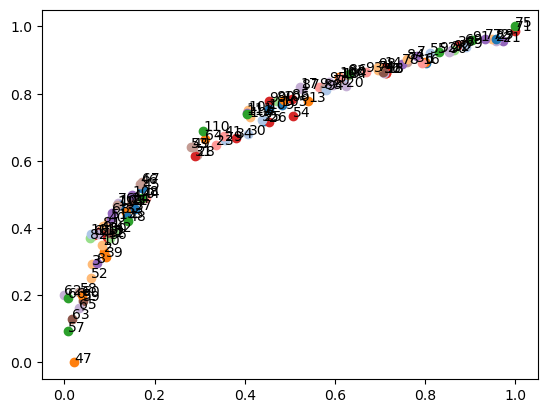

＝＝＝＝＝＝＝＝＝＝＝＝＝＝クラスタリング結果＝＝＝＝＝＝＝＝＝＝＝＝＝＝


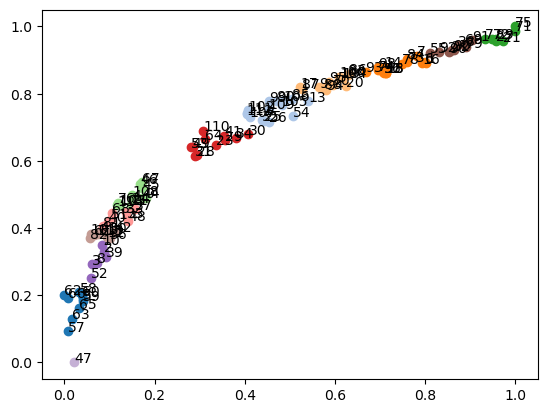

0.03093893281544681


In [68]:
#埋め込みを各軸で正規化
max_vec_c = MinMaxScaler().fit_transform(max_vec)

    # 埋め込み結果を可視化
print("＝＝＝＝＝＝＝＝埋め込み結果（正解ラベルに基づいて色付け）＝＝＝＝＝＝＝＝＝")
deepwalk.draw_embedded_vector(max_vec_c, colorlist=TRUE_LABEL)
# クラスタリング結果に基づいて可視化
print("＝＝＝＝＝＝＝＝＝＝＝＝＝＝クラスタリング結果＝＝＝＝＝＝＝＝＝＝＝＝＝＝")
deepwalk.draw_embedded_vector(max_vec_c,colorlist = max_pred)
print(max(ARI_list))


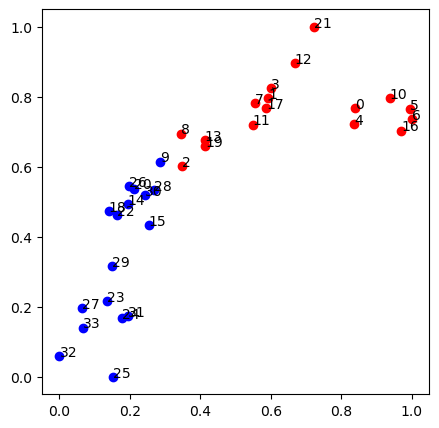

In [36]:
colorlist = TRUE_LABEL
Y = max_vec_c
node_annotation = None



fig , ax = plt.subplots(figsize=(5,5))
for i in range(len(Y)):

    if node_annotation != None:
        if node_annotation[i] in attention_nodelist:
            ax.annotate(str(node_annotation[i]), (Y[i,0],Y[i,1]) ,color="red")
        else:
            ax.annotate(str(node_annotation[i]), (Y[i,0],Y[i,1]))
    else:
        ax.annotate(str(i), (Y[i,0],Y[i,1]))
    
    if node_annotation != None:

        if node_annotation[i] in attention_nodelist:
            ax.scatter(Y[i,0],Y[i,1],c="red")
        else:
            ax.scatter(Y[i,0],Y[i,1],c=[plt.cm.tab20(colorlist[i])])
    else:
        if colorlist[i]==0:
            ax.scatter(Y[i,0],Y[i,1],c="red")
        else:  
            ax.scatter(Y[i,0],Y[i,1],c="blue")

     
plt.show()

In [ ]:
#maxvecをcsvに出力
with open(f"max_vec_{data}_exec-{NUMBER_WALKS}_walklength-{WALK_LENGTH}_window-{WINDOW_SIZE}_method-{METHOD}.csv", "w") as f:
    for i in range(len(max_vec)):
        f.write(f"{max_vec[i][0]},{max_vec[i][1]}\n")
